In [17]:
import pandas as pd

path = "/Users/diandra/Downloads/EA_WaterIoT/dataset/water_potability.csv"
data = pd.read_csv(path)

data.head()
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [18]:
data.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [19]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [20]:
from sklearn.ensemble import RandomForestClassifier

RF_model_before_aug = RandomForestClassifier()

# print("===============================================================================")

RF_model_after_aug = RandomForestClassifier()

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

data.fillna(data.median(), inplace=True)  # Handle missing values

X = data.drop(columns='Potability')  # Assuming 'label' is the target column
y = data['Potability']

# Check class distribution before split & SMOTE
print("Class distribution before split & SMOTE:")
print(y.value_counts())

Class distribution before split & SMOTE:
Potability
0    1998
1    1278
Name: count, dtype: int64


In [23]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check class distribution after split before SMOTE
print("Class distribution after split before SMOTE:")
print(y_train.value_counts())

Class distribution after split before SMOTE:
Potability
0    1586
1    1034
Name: count, dtype: int64


In [24]:
RF_model_before_aug.fit(X_train, y_train)

RF_pred = RF_model_before_aug.predict(X_test)
print("Random Forest before SMOTE Classification Report:\n\n", classification_report(y_test, RF_pred))
print("Random Forest before SMOTE Accuracy Score:", accuracy_score(y_test, RF_pred))

Random Forest before SMOTE Classification Report:

               precision    recall  f1-score   support

           0       0.68      0.86      0.76       412
           1       0.58      0.33      0.42       244

    accuracy                           0.66       656
   macro avg       0.63      0.59      0.59       656
weighted avg       0.65      0.66      0.64       656

Random Forest before SMOTE Accuracy Score: 0.663109756097561


In [25]:
# Resample data to handle class imbalance using SMOTE
smote = SMOTE()
X_aug, y_aug = smote.fit_resample(X, y)

# Check class distribution after SMOTE before split
print("Class distribution after SMOTE before split:")
print(y_aug.value_counts())

print("===============================================================================")

X_aug_train, X_aug_test, y_aug_train, y_aug_test = train_test_split(X_aug, y_aug, test_size=0.2, random_state=42)

# Check class distribution after SMOTE & Split
print("Class distribution after SMOTE & Split:")
print(y_aug_train.value_counts())

Class distribution after SMOTE before split:
Potability
0    1998
1    1998
Name: count, dtype: int64
Class distribution after SMOTE & Split:
Potability
0    1604
1    1592
Name: count, dtype: int64


In [26]:
RF_model_after_aug.fit(X_aug_train, y_aug_train)

RF_pred = RF_model_after_aug.predict(X_aug_test)
print("Random Forest after SMOTE & split Classification Report:\n\n", classification_report(y_aug_test, RF_pred))
print("Random Forest after SMOTE & split Accuracy Score:", accuracy_score(y_aug_test,RF_pred))

Random Forest after SMOTE & split Classification Report:

               precision    recall  f1-score   support

           0       0.68      0.70      0.69       394
           1       0.70      0.69      0.69       406

    accuracy                           0.69       800
   macro avg       0.69      0.69      0.69       800
weighted avg       0.69      0.69      0.69       800

Random Forest after SMOTE & split Accuracy Score: 0.6925


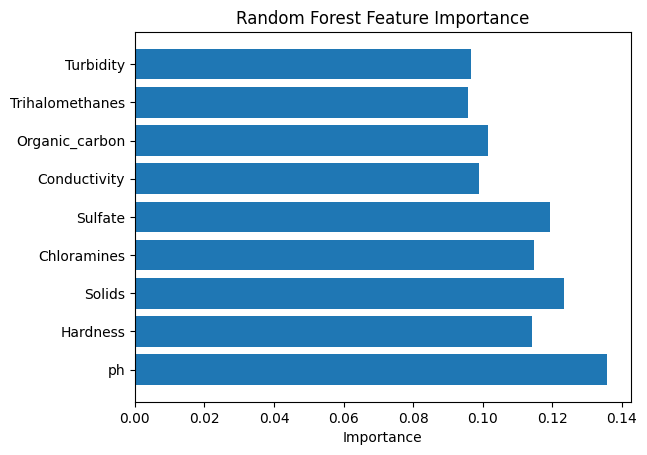

In [27]:
import matplotlib.pyplot as plt
importances = RF_model_after_aug.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.show()